<a href="https://colab.research.google.com/github/surohit700/Assignmentextension/blob/main/salary_prediction_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# python
import pandas as pd
import numpy as np
import matplotlib.pyplot

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
#dataset load

df = pd.read_csv('/content/drive/MyDrive/job_salary_prediction_dataset.csv')
df

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069
...,...,...,...,...,...,...,...,...,...,...
249995,Software Engineer,17,PhD,2,Telecom,Enterprise,India,No,1,127791
249996,Frontend Developer,20,PhD,7,Telecom,Startup,Remote,No,2,154593
249997,Business Analyst,1,Bachelor,12,Retail,Enterprise,India,Yes,0,75988
249998,Data Scientist,0,High School,2,Consulting,Small,Sweden,Hybrid,5,90467


In [6]:
# data preprocessing

print(df.head())
print(df.info())
print(df.describe())

            job_title  experience_years education_level  skills_count  \
0         AI Engineer                10        Bachelor             2   
1        Data Analyst                 5        Bachelor            17   
2  Frontend Developer                18             PhD             4   
3    Business Analyst                19             PhD            13   
4     Product Manager                15        Bachelor             7   

        industry company_size   location remote_work  certifications  salary  
0     Healthcare       Medium      India      Hybrid               2  109413  
1        Telecom        Small  Australia          No               0   93764  
2          Media       Medium  Singapore          No               1  148123  
3         Retail       Medium     Canada         Yes               0  189123  
4  Manufacturing        Large     Sweden         Yes               0  165069  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data colu

In [7]:
df.describe()

,experience_years,skills_count,certifications,salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000


In [8]:
print(df['salary'].mean())
print(df['salary'].median())
print(df['salary'].max())
print(df['salary'].mode())


145718.080524
143453.0
333046
0    140468
Name: salary, dtype: int64


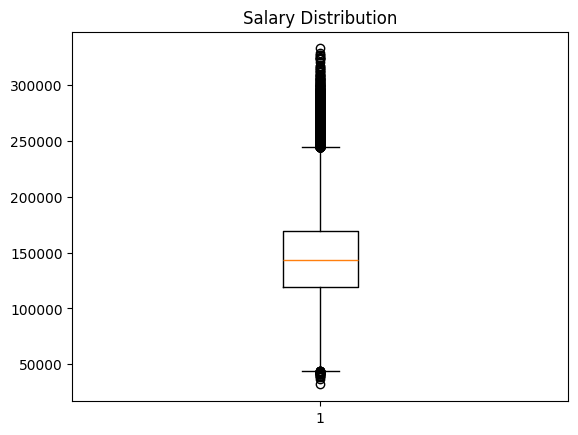

In [9]:
import matplotlib.pyplot as plt

plt.boxplot(df['salary'])
plt.title('Salary Distribution')
plt.show()


In [10]:
print(df.columns)
print(df.describe())

Index(['job_title', 'experience_years', 'education_level', 'skills_count',
       'industry', 'company_size', 'location', 'remote_work', 'certifications',
       'salary'],
      dtype='object')
       experience_years   skills_count  certifications         salary
count     250000.000000  250000.000000   250000.000000  250000.000000
mean          10.005408       9.997812        2.491928  145718.080524
std            6.060602       5.479288        1.706475   37407.952729
min            0.000000       1.000000        0.000000   31867.000000
25%            5.000000       5.000000        1.000000  119358.000000
50%           10.000000      10.000000        2.000000  143453.000000
75%           15.000000      15.000000        4.000000  169492.000000
max           20.000000      19.000000        5.000000  333046.000000


In [11]:
numeric_cols = ['experience_years', 'skills_count', 'certifications', 'salary']
print(df[numeric_cols].corr())

                  experience_years  skills_count  certifications    salary
experience_years          1.000000      0.000149       -0.000198  0.437627
skills_count              0.000149      1.000000       -0.002230  0.127300
certifications           -0.000198     -0.002230        1.000000  0.073819
salary                    0.437627      0.127300        0.073819  1.000000


In [12]:
print(df['skills_count'].describe())
print(df['skills_count'].median())

count    250000.000000
mean          9.997812
std           5.479288
min           1.000000
25%           5.000000
50%          10.000000
75%          15.000000
max          19.000000
Name: skills_count, dtype: float64
10.0


In [13]:
print(df['education_level'])

0            Bachelor
1            Bachelor
2                 PhD
3                 PhD
4            Bachelor
             ...     
249995            PhD
249996            PhD
249997       Bachelor
249998    High School
249999        Diploma
Name: education_level, Length: 250000, dtype: object


In [14]:
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
import pandas as pd

# Education Level - Ordinal Encoding
education_order = ['High School', 'Diploma','Bachelor', 'Master', 'PhD']
oe = OrdinalEncoder(categories=[education_order])
df['education_encoded'] = oe.fit_transform(df[['education_level']])

# Final features select karo
features = ['experience_years', 'skills_count', 'certifications', 'education_encoded']
X = df[features]
y = df['salary']

print(X.head())


   experience_years  skills_count  certifications  education_encoded
0                10             2               2                2.0
1                 5            17               0                2.0
2                18             4               1                4.0
3                19            13               0                4.0
4                15             7               0                2.0


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 200000
Testing rows: 50000


In [16]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained!")

Model trained!


In [17]:
y_pred = model.predict(X_test)
print(y_pred[:5])

[146595.28780787 146702.42589424 142762.53774874 141833.2061676
 120102.3536271 ]


In [18]:
import pandas as pd

comparison = pd.DataFrame({
    'Actual Salary': y_test[:5].values,
    'Predicted Salary': y_pred[:5]
})
print(comparison)

   Actual Salary  Predicted Salary
0         164009     146595.287808
1          79594     146702.425894
2          74090     142762.537749
3         177193     141833.206168
4         120012     120102.353627


In [19]:
from sklearn.metrics import r2_score, mean_absolute_error

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("R2 Score:", r2)
print("MAE:", mae)

R2 Score: 0.30405059253019007
MAE: 24550.823843514238


In [20]:
df.columns

Index(['job_title', 'experience_years', 'education_level', 'skills_count',
       'industry', 'company_size', 'location', 'remote_work', 'certifications',
       'salary', 'education_encoded'],
      dtype='object')

In [21]:
# Job Title ki unique values dekho pehle
print(df['job_title'].nunique())
print(df['job_title'].value_counts().head(20))

12
job_title
Backend Developer            21125
Cybersecurity Analyst        20959
Product Manager              20950
AI Engineer                  20945
Data Scientist               20890
DevOps Engineer              20889
Software Engineer            20876
Data Analyst                 20722
Cloud Engineer               20686
Machine Learning Engineer    20677
Business Analyst             20648
Frontend Developer           20633
Name: count, dtype: int64


In [22]:
job_category = {
    'Backend Developer': 'Developer',
    'Frontend Developer': 'Developer',
    'Software Engineer': 'Engineer',
    'AI Engineer': 'Engineer',
    'DevOps Engineer': 'Engineer',
    'Cloud Engineer': 'Engineer',
    'Machine Learning Engineer': 'Engineer',
    'Data Scientist': 'Analyst',
    'Data Analyst': 'Analyst',
    'Business Analyst': 'Analyst',
    'Cybersecurity Analyst': 'Analyst',
    'Product Manager': 'Manager'
}

df['job_category'] = df['job_title'].map(job_category)
print(df['job_category'].value_counts())

job_category
Engineer     104073
Analyst       83219
Developer     41758
Manager       20950
Name: count, dtype: int64


In [23]:
df = pd.get_dummies(df, columns=['job_category'])
print(df.columns)

Index(['job_title', 'experience_years', 'education_level', 'skills_count',
       'industry', 'company_size', 'location', 'remote_work', 'certifications',
       'salary', 'education_encoded', 'job_category_Analyst',
       'job_category_Developer', 'job_category_Engineer',
       'job_category_Manager'],
      dtype='object')


In [24]:
features = [
    'experience_years',
    'skills_count',
    'certifications',
    'education_encoded',
    'job_category_Analyst',
    'job_category_Developer',
    'job_category_Engineer',
    'job_category_Manager'
]

X = df[features]
y = df['salary']

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model train karo
model = LinearRegression()
model.fit(X_train, y_train)

# Score dekho
y_pred = model.predict(X_test)
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2 Score: 0.38668803600441426
MAE: 22827.541636741862


In [25]:
print(df['industry'].nunique())
print(df['location'].nunique())
print(df['industry'].value_counts())
print(df['location'].value_counts())

10
10
industry
Finance          25393
Consulting       25258
Media            25034
Manufacturing    25024
Technology       24903
Government       24901
Healthcare       24898
Education        24889
Telecom          24859
Retail           24841
Name: count, dtype: int64
location
Australia      25258
Canada         25165
Sweden         25100
Remote         25065
Singapore      25035
USA            24931
UK             24927
India          24895
Netherlands    24861
Germany        24763
Name: count, dtype: int64


In [26]:
df = pd.get_dummies(df, columns=['industry', 'location'])

# Updated features
features = [
    'experience_years',
    'skills_count',
    'certifications',
    'education_encoded',
    'job_category_Analyst',
    'job_category_Developer',
    'job_category_Engineer',
    'job_category_Manager',
] + [col for col in df.columns if col.startswith('industry_') or col.startswith('location_')]

X = df[features]
y = df['salary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2 Score: 0.7086772485694062
MAE: 16285.325858991453


In [27]:
# remote_work ka encoding
df = pd.get_dummies(df, columns=['remote_work'])

features = [
    'experience_years',
    'skills_count',
    'certifications',
    'education_encoded',
    'job_category_Analyst',
    'job_category_Developer',
    'job_category_Engineer',
    'job_category_Manager',
] + [col for col in df.columns if col.startswith('industry_')
     or col.startswith('location_')
     or col.startswith('remote_work_')]

X = df[features]
y = df['salary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2 Score: 0.7134083675493981
MAE: 16171.539350105983


In [29]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
print("R2 Score:", r2_score(y_test, y_pred_rf))
print("MAE:", mean_absolute_error(y_test, y_pred_rf))

R2 Score: 0.6865526432367877
MAE: 16793.141485586813


In [30]:
rf_model = RandomForestRegressor(
    n_estimators=200,  # 100 se 200 kiya
    random_state=42,
    n_jobs=-1  # saare CPU cores use karega — fast hoga
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
print("R2 Score:", r2_score(y_test, y_pred_rf))
print("MAE:", mean_absolute_error(y_test, y_pred_rf))

R2 Score: 0.6881178099348455
MAE: 16753.95684442166


In [31]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)
gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)
print("R2 Score:", r2_score(y_test, y_pred_gb))
print("MAE:", mean_absolute_error(y_test, y_pred_gb))

R2 Score: 0.7183265481398058
MAE: 16005.998215800993
